# Aprendizaje Estadístico y Data Mining

## Práctica Final: Pacientes con Esquizofrenia

### Formulación de Objetivos
**Hipótesis:** Los pacientes con esquizofrenia y un inicio temprano de la enfermedad tienen perfiles de síntomas psicóticos distintos a los de los pacientes con un inicio tardío.  

**Plan de Resolución:** Para demostrar la hipótesis, realizaremos técnicas de clusterización, de tal manera que podamos diferenciar dos tipos de paciente, agrupados de manera diferente a sus síntomas psicóticos. En caso de que los clústeres se correspondan con los grupos de edad, sería un indicativo de que la hipótesis se cumpliría. Utilizaremos el dataset *schizo.csv*, que recoge más de 3000 datos de pacientes de esquizofrenia en la ciudad de Moscú. [Fuente](https://pmc.ncbi.nlm.nih.gov/articles/PMC8749170/)

Para ello, vamos a realizar dos grupos:  
- **Inicio Temprano:** Pacientes cuya edad de inicio sea menor de 18 años.
- **Inicio Tardío:** Pacientes cuya edad de inicio sea mayor o igual a 18 años.

#### Librerías Necesarias

Instalación de librerías:

In [50]:
#%pip install pandas scikit-learn numpy matplotlib scipy ipympl

Importación de las librerias:

In [ ]:
%matplotlib widget
import pandas as pd # type: ignore
import scipy.cluster.hierarchy as sch # type: ignore
import matplotlib.pyplot as plt # type: ignore
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.cluster import KMeans
import numpy as np # type: ignore




### Preprocesamiento de los Datos
En primer lugar, comenzaremos cargando nuestro dataset y realizando una limpieza de columnas. En este caso, por el momento nos quedaremos con las columnas de los síntomas psicóticos. En el caso de los datos nulos, en caso de ser en los síntomas, supondremos que es que no presenta ese síntoma, por lo que lo transformaremos en 0.

In [52]:
df = pd.read_csv("data/schizo.csv", sep=";", engine="python", on_bad_lines='skip')

columnas_sintomas = [
    'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7',      # PANSS positivo
    'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7',      # PANSS negativo
    'g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'g7', 'g8', # PANSS general
    'g9', 'g10', 'g11', 'g12', 'g13', 'g14', 'g15', 'g16'
]

df_sintomas = df[columnas_sintomas].copy()

df_sintomas = df_sintomas.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sintomas)

### Clustering

K = 1, Inercia = 90119.99999999997
K = 2, Inercia = 70890.43813260748
K = 3, Inercia = 64036.09142221731
K = 4, Inercia = 60084.47880288669
K = 5, Inercia = 56502.06339681087
K = 6, Inercia = 54561.73856977828
K = 7, Inercia = 52837.04813881169
K = 8, Inercia = 51334.37636277918
K = 9, Inercia = 50180.80242957486
K = 10, Inercia = 49241.571953560444


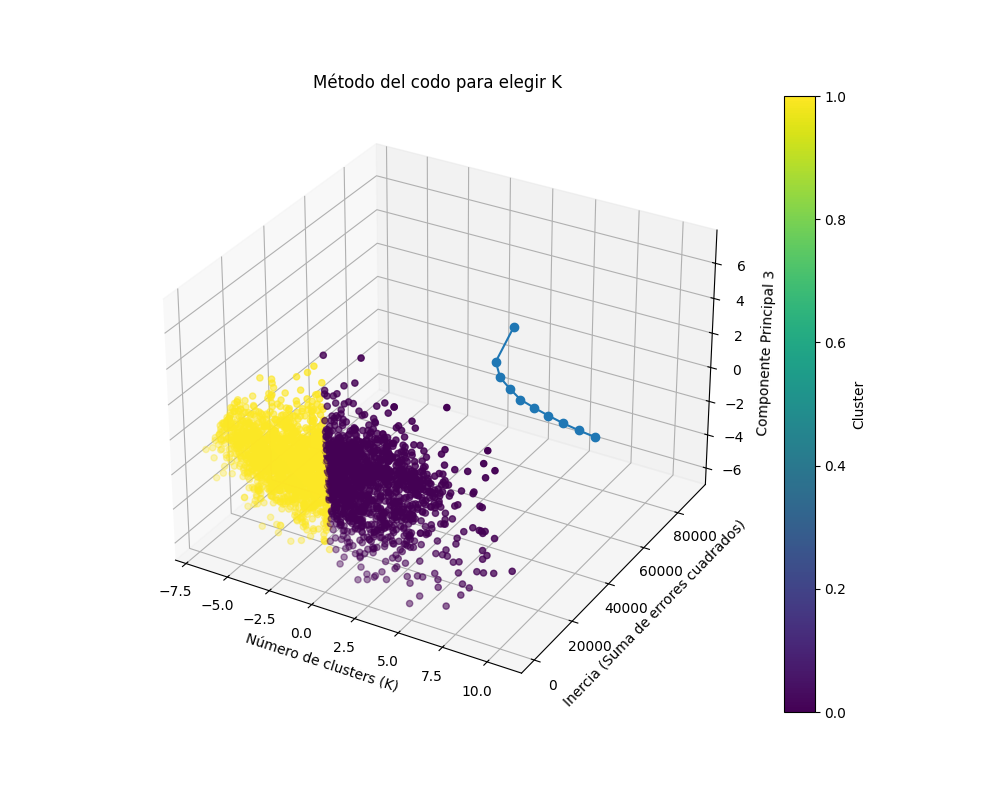

In [ ]:
# Evaluamos K de 1 a 10
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
    print(f"K = {k}, Inercia = {kmeans.inertia_}")

# Graficar la curva del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia (Suma de errores cuadrados)')
plt.title('Método del codo para elegir K')
plt.grid(True)
plt.show()


In [54]:
# Aplicamos K-means con K=4
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Añadir los clusters al DataFrame original
df['cluster'] = clusters

# Ver los primeros registros con el cluster asignado
print(df[['ID', 'cluster']].head())

     ID  cluster
0   125        0
1    81        0
2   333        0
3  1685        0
4    27        1


In [55]:
df_cluster_summary = df.groupby('cluster')[columnas_sintomas].mean()

display(df_cluster_summary)

,p1,p2,p3,p4,p5,p6,p7,n1,n2,n3,...,g7,g8,g9,g10,g11,g12,g13,g14,g15,g16
cluster,,,,,,,,,,,,,,,,,,,,,
0,5.173751,4.929955,4.158837,3.476900,2.595380,4.307233,3.519016,4.393625,4.217939,4.242402,...,2.724777,3.219005,3.992582,1.806523,3.727947,4.960682,3.978487,2.377317,4.164566,4.103935
1,4.748000,4.523682,3.772667,3.298199,2.272667,3.877333,2.846462,2.858006,2.591898,2.486405,...,1.623714,1.528131,2.026618,1.134627,2.214891,3.074410,2.443705,1.332123,2.051453,1.982414


In [56]:
# Ver cómo se distribuyen los clusters según la edad de inicio
moda_por_cluster = df.groupby('cluster')['age at onset (y.o.)'].apply(lambda x: x.mode()[0])
display(moda_por_cluster)

cluster
0    17.0
1    20.0
Name: age at onset (y.o.), dtype: float64

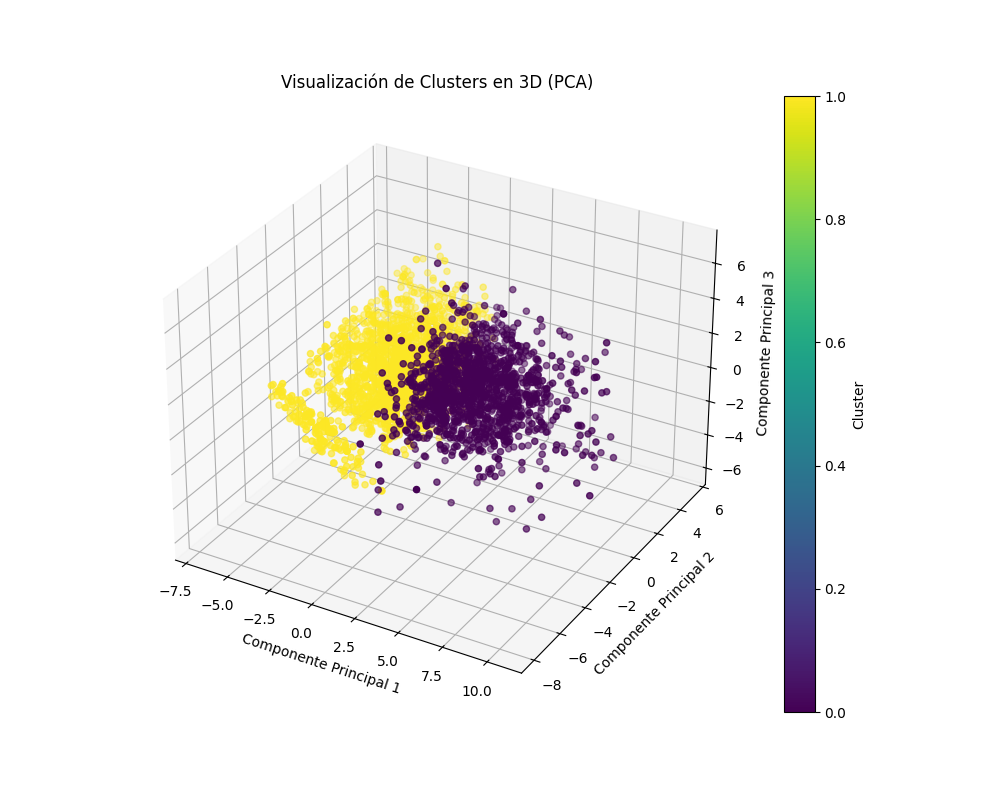

In [57]:
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=df['cluster'], cmap='viridis')

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.set_title('Visualización de Clusters en 3D (PCA)')


cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')


plt.show()